In [1]:
import numpy as np
import opendatasets as od
import pandas as pd
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from wordcloud import WordCloud, STOPWORDS
from sklearn.decomposition import LatentDirichletAllocation
from collections import Counter
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
import scipy.stats as stats
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.manifold import TSNE
import warnings
warnings.simplefilter("ignore")

In [3]:
dataset = pd.read_csv(r"C:\Users\lordpato\Desktop\sentiment analysis\tweet.csv")

In [5]:
print(dataset.head())

   Unnamed: 0                       Date             User  \
0           0  2023-03-14 23:38:44+00:00        DotieGreg   
1           1  2023-03-14 22:54:06+00:00   RelevantNewsNg   
2           2  2023-03-14 22:39:19+00:00  SYLVESTERSELAB1   
3           3  2023-03-14 22:28:38+00:00         TA_LI_01   
4           4  2023-03-14 22:16:22+00:00      ramseyogaga   

            DisplayName                                            Content  \
0      OMEGATV123H NEWS  WATCH HOW #INEC AND #APC RIGGED THE ELECTION A...   
1          RelevantNews  PROF SAHEED TO TINUBU \nThis is a BLAST 🔥🔥\n#I...   
2             Sylvester  @inecnigeria Questions:\nWhy do #INEC post vit...   
3          Tali Nanzing  Trust me when I say we didn't just win but we ...   
4  Rev Ramsey O.Jeffrey  This new language of @obidents is not a party ...   

   Followers  Retweet  Likes                   location  \
0         96        0      0       Lagos state Nigeria    
1         56        0      0             Abuja

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [9]:
# Preprocess your data
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(dataset['Tweet'])
y = dataset['Analysis']  # assuming 'Analysis' is your sentiment label column

In [11]:
# Split your data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
import pandas as pd
import numpy as np
import re
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [15]:
# Load your dataset
dataset = pd.read_csv(r"C:\Users\lordpato\Desktop\sentiment analysis\tweet.csv")



In [17]:
# Define a function to preprocess Nigerian Pidgin English text
def preprocess_text(text):
    # Tokenize text
    tokenizer = WordPunctTokenizer()
    tokens = tokenizer.tokenize(text)


In [19]:
# Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t.lower() not in stop_words]
    


IndentationError: unexpected indent (2340233104.py, line 2)

In [21]:
def preprocess_text(text):
    # Tokenize text
    tokenizer = WordPunctTokenizer()
    tokens = tokenizer.tokenize(text)

    # Remove stopwords
stop_words = set(stopwords.words('english'))
tokens = [t for t in tokens if t.lower() not in stop_words]

    # Remove special characters and digits
tokens = [re.sub(r'[^a-zA-Z]', '', t) for t in tokens]

    # Join tokens back into a string
text = ' '.join(tokens)


NameError: name 'tokens' is not defined

In [23]:
tokenizer = WordPunctTokenizer()
tokens = tokenizer.tokenize(text)




NameError: name 'text' is not defined

In [25]:
import pandas as pd
import numpy as np
import re
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [27]:
# Define a function to preprocess Nigerian Pidgin English text
def preprocess_text(text):
    # Tokenize text
    tokenizer = WordPunctTokenizer()
    tokens = tokenizer.tokenize(text)


In [29]:
 # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t.lower() not in stop_words]



IndentationError: unexpected indent (1938787389.py, line 2)

In [31]:
# Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t.lower() not in stop_words]



IndentationError: unexpected indent (2439358474.py, line 2)

In [33]:
# Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t.lower() not in stop_words]

IndentationError: unexpected indent (2954050411.py, line 2)

In [35]:
def preprocess_text(text):
  tokenizer = WordPunctTokenizer()
  tokens = tokenizer.tokenize(text)
  stop_words = set(stopwords.words('english'))
  tokens = [t for t in tokens if t.lower() not in stop_words]
  tokens = [re.sub(r'[^a-zA-Z]', '', t) for t in tokens]
  text = ' '.join(tokens)
  return text

In [37]:
# Load your dataset
dataset = pd.read_csv(r"C:\Users\lordpato\Desktop\sentiment analysis\tweet.csv")


In [39]:
# Apply preprocessing to your dataset
dataset['Content'] = dataset['Content'].apply(preprocess_text)

In [41]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(dataset['Content'], dataset['Polarity'], test_size=0.2, random_state=42)


In [43]:
# Create a TF-IDF vectorizer
vectorizer = TfidfVectorizer()

In [45]:
# Fit the vectorizer to the training data and transform both the training and testing data
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [49]:
# Convert target variable into categorical classes
y_train = np.where(y_train > 0, 1, 0)
y_test = np.where(y_test > 0, 1, 0)


In [51]:
# Train a Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)


RandomForestClassifier(random_state=42)

In [53]:
y_pred = rf.predict(X_test_tfidf)


In [55]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Random Forest accuracy: {accuracy:.3f}')
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Random Forest accuracy: 0.836
              precision    recall  f1-score   support

           0       0.81      0.95      0.88      1216
           1       0.90      0.65      0.76       784

    accuracy                           0.84      2000
   macro avg       0.86      0.80      0.82      2000
weighted avg       0.85      0.84      0.83      2000

[[1161   55]
 [ 274  510]]


In [57]:
import pandas as pd
import numpy as np
import re
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle


In [59]:
dataset = pd.read_csv(r"C:\Users\lordpato\Desktop\sentiment analysis\tweet.csv")

In [65]:
# Load your dataset
dataset = pd.read_csv(r"C:\Users\lordpato\Desktop\sentiment analysis\tweet.csv")

In [69]:
# Add a new column with the candidate's name
dataset['candidate'] = dataset['Content'].apply(lambda x: 'Atiku' if 'Atiku' in x else 'Tinubu' if 'Tinubu' in x else 'Peter Obi' if 'Peter Obi' in x else 'None')


In [75]:

candidates = ['Atiku', 'Tinubu', 'Peter Obi']
for candidate in candidates:
    candidate_df = dataset[dataset['candidate'] == candidate]
    candidate_df['sentiment'] = np.where(candidate_df['Subjectivity'] > 0.5, 1, 0)
    X_train, X_test, y_train, y_test = train_test_split(candidate_df['Content'], candidate_df['sentiment'], test_size=0.2, random_state=42)
    vectorizer = TfidfVectorizer()
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_tfidf, y_train)
    y_pred = rf.predict(X_test_tfidf)
    print(f'{candidate} model accuracy: {accuracy_score(y_test, y_pred):.3f}')


Atiku model accuracy: 0.769
Tinubu model accuracy: 0.750
Peter Obi model accuracy: 0.714


In [80]:
# Filter the dataset for Atiku
atiku_df = dataset[dataset['candidate'] == 'Atiku']


In [81]:
# Filter the dataset for Atiku
atiku_df = dataset[dataset['candidate'] == 'Atiku']

In [87]:
# Import the SentimentIntensityAnalyzer class from the nltk.sentiment.vader module
from nltk.sentiment.vader import SentimentIntensityAnalyzer


In [89]:
# Create an instance of the SentimentIntensityAnalyzer class
sia = SentimentIntensityAnalyzer()


In [91]:
# Filter the dataset for Atiku
atiku_df = dataset[dataset['candidate'] == 'Atiku']


In [93]:
# Perform sentiment analysis on the 'Content' column
atiku_df['sentiment'] = atiku_df['Content'].apply(lambda x: sia.polarity_scores(x)['compound'])


In [95]:
# Print the sentiment scores
print(atiku_df['sentiment'])


68      0.0000
315     0.5574
593     0.0000
624     0.3612
689     0.0000
         ...  
9560   -0.7889
9709    0.7527
9861    0.0000
9895    0.0000
9983   -0.3400
Name: sentiment, Length: 195, dtype: float64


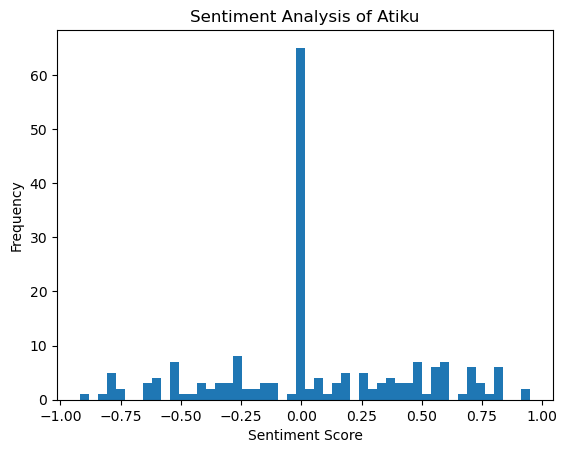

In [97]:
# Plot a histogram of the sentiment scores
import matplotlib.pyplot as plt
atiku_df['sentiment'].plot.hist(bins=50)
plt.title('Sentiment Analysis of Atiku')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()


In [99]:
# Define a function to categorize sentiment scores
def categorize_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'


In [101]:
# Apply the function to the sentiment scores
atiku_df['sentiment_category'] = atiku_df['sentiment'].apply(categorize_sentiment)


In [103]:
# Print the updated dataframe
print(atiku_df)


      Unnamed: 0                       Date             User  \
68            68  2023-03-14 14:15:19+00:00   AdeolaAbidoye1   
315          315  2023-03-13 10:32:56+00:00  ADEKUNLEOlush17   
593          593  2023-03-11 16:01:55+00:00      AriyaXpress   
624          624  2023-03-11 11:16:50+00:00         GhanniyO   
689          689  2023-03-11 06:45:12+00:00        naijnaira   
...          ...                        ...              ...   
9560        9560  2023-02-26 18:54:25+00:00       D_beast_01   
9709        9709  2023-02-26 18:06:12+00:00       Mc_Thespis   
9861        9861  2023-02-26 17:05:45+00:00    notice_com_ng   
9895        9895  2023-02-26 16:48:27+00:00        Atmturaki   
9983        9983  2023-02-26 15:59:16+00:00    notice_com_ng   

                      DisplayName  \
68                 Adeola Abidoye   
315             ADEKUNLE Olushola   
593                   AriyaXpress   
624           Last Week in Africa   
689                     NaijNaira   
...      

In [105]:
# Categorize sentiment scores as percentages
positive_count = len(atiku_df[atiku_df['sentiment_category'] == 'Positive'])
negative_count = len(atiku_df[atiku_df['sentiment_category'] == 'Negative'])
neutral_count = len(atiku_df[atiku_df['sentiment_category'] == 'Neutral'])

In [107]:

total_count = positive_count + negative_count + neutral_count

In [109]:
positive_percentage = (positive_count / total_count) * 100
negative_percentage = (negative_count / total_count) * 100
neutral_percentage = (neutral_count / total_count) * 100


In [111]:

print(f'Positive: {positive_percentage:.2f}%')
print(f'Negative: {negative_percentage:.2f}%')
print(f'Neutral: {neutral_percentage:.2f}%')


Positive: 37.95%
Negative: 28.21%
Neutral: 33.85%


In [113]:
# Plot a histogram
import matplotlib.pyplot as plt


In [115]:
labels = ['Positive', 'Negative', 'Neutral']
sizes = [positive_percentage, negative_percentage, neutral_percentage]


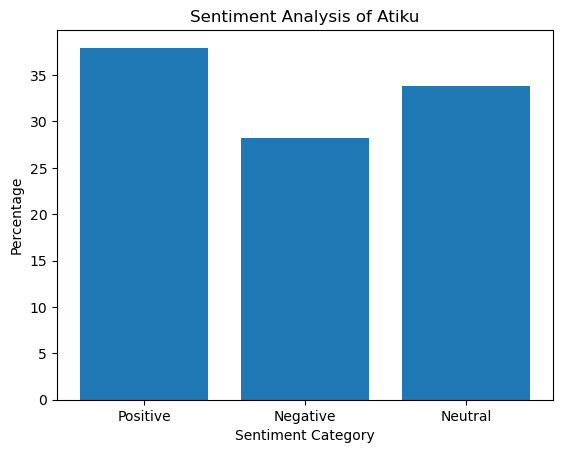

In [117]:
plt.bar(labels, sizes)
plt.xlabel('Sentiment Category')
plt.ylabel('Percentage')
plt.title('Sentiment Analysis of Atiku')
plt.show()


In [119]:
peter_obi_df = dataset[dataset['candidate'] == 'Peter Obi']

In [121]:
peter_obi_df['sentiment'] = peter_obi_df['Content'].apply(lambda x: sia.polarity_scores(x)['compound'])


In [123]:
peter_obi_df['sentiment_category'] = peter_obi_df['sentiment'].apply(categorize_sentiment)


In [125]:
positive_count = len(peter_obi_df[peter_obi_df['sentiment_category'] == 'Positive'])
negative_count = len(peter_obi_df[peter_obi_df['sentiment_category'] == 'Negative'])
neutral_count = len(peter_obi_df[peter_obi_df['sentiment_category'] == 'Neutral'])


In [127]:
total_count = positive_count + negative_count + neutral_count


In [129]:

positive_percentage = (positive_count / total_count) * 100
negative_percentage = (negative_count / total_count) * 100
neutral_percentage = (neutral_count / total_count) * 100


In [131]:

print(f'Positive: {positive_percentage:.2f}%')
print(f'Negative: {negative_percentage:.2f}%')
print(f'Neutral: {neutral_percentage:.2f}%')


Positive: 50.41%
Negative: 31.82%
Neutral: 17.77%


In [133]:
labels = ['Positive', 'Negative', 'Neutral']
sizes = [positive_percentage, negative_percentage, neutral_percentage]


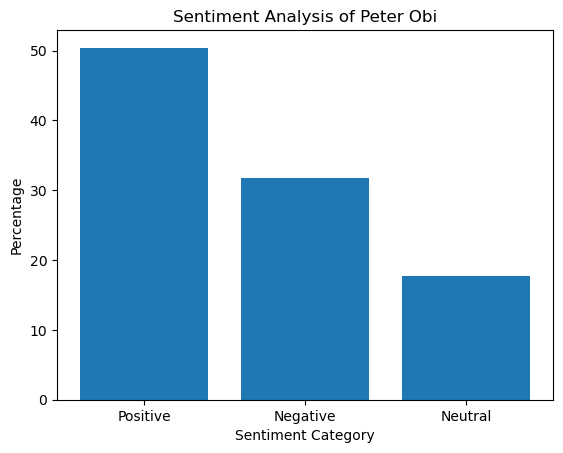

In [135]:
plt.bar(labels, sizes)
plt.xlabel('Sentiment Category')
plt.ylabel('Percentage')
plt.title('Sentiment Analysis of Peter Obi')
plt.show()


In [137]:
tinubu_df = dataset[dataset['candidate'] == 'Tinubu']


In [139]:
tinubu_df['sentiment'] = tinubu_df['Content'].apply(lambda x: sia.polarity_scores(x)['compound'])


In [141]:
tinubu_df['sentiment_category'] = tinubu_df['sentiment'].apply(categorize_sentiment)


In [143]:
positive_count = len(tinubu_df[tinubu_df['sentiment_category'] == 'Positive'])
negative_count = len(tinubu_df[tinubu_df['sentiment_category'] == 'Negative'])
neutral_count = len(tinubu_df[tinubu_df['sentiment_category'] == 'Neutral'])


In [145]:
total_count = positive_count + negative_count + neutral_count


In [147]:

positive_percentage = (positive_count / total_count) * 100
negative_percentage = (negative_count / total_count) * 100
neutral_percentage = (neutral_count / total_count) * 100


In [149]:
print(f'Positive: {positive_percentage:.2f}%')
print(f'Negative: {negative_percentage:.2f}%')
print(f'Neutral: {neutral_percentage:.2f}%')


Positive: 49.49%
Negative: 26.86%
Neutral: 23.65%


In [151]:
labels = ['Positive', 'Negative', 'Neutral']
sizes = [positive_percentage, negative_percentage, neutral_percentage]


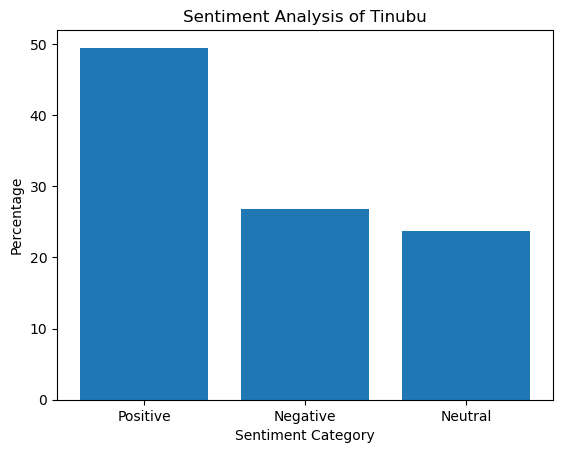

In [153]:
plt.bar(labels, sizes)
plt.xlabel('Sentiment Category')
plt.ylabel('Percentage')
plt.title('Sentiment Analysis of Tinubu')
plt.show()


In [155]:
# Calculate overall sentiment scores and categories for each candidate
atiku_positive = len(atiku_df[atiku_df['sentiment_category'] == 'Positive'])
atiku_negative = len(atiku_df[atiku_df['sentiment_category'] == 'Negative'])
atiku_neutral = len(atiku_df[atiku_df['sentiment_category'] == 'Neutral'])


In [157]:
peter_obi_positive = len(peter_obi_df[peter_obi_df['sentiment_category'] == 'Positive'])
peter_obi_negative = len(peter_obi_df[peter_obi_df['sentiment_category'] == 'Negative'])
peter_obi_neutral = len(peter_obi_df[peter_obi_df['sentiment_category'] == 'Neutral'])


In [159]:
tinubu_positive = len(tinubu_df[tinubu_df['sentiment_category'] == 'Positive'])
tinubu_negative = len(tinubu_df[tinubu_df['sentiment_category'] == 'Negative'])
tinubu_neutral = len(tinubu_df[tinubu_df['sentiment_category'] == 'Neutral'])


In [161]:
# Create a comparative bar chart
labels = ['Positive', 'Negative', 'Neutral']
atiku_sizes = [atiku_positive, atiku_negative, atiku_neutral]
peter_obi_sizes = [peter_obi_positive, peter_obi_negative, peter_obi_neutral]
tinubu_sizes = [tinubu_positive, tinubu_negative, tinubu_neutral]


In [163]:
plt.bar(x - width, atiku_sizes, width, label='Atiku')
plt.bar(x, peter_obi_sizes, width, label='Peter Obi')
plt.bar(x + width, tinubu_sizes, width, label='Tinubu')


NameError: name 'x' is not defined

In [165]:
import numpy as np


In [167]:
# Define 'x'
x = np.arange(len(labels))


In [169]:
# Create a comparative bar chart
plt.bar(x - width, atiku_sizes, width, label='Atiku')
plt.bar(x, peter_obi_sizes, width, label='Peter Obi')
plt.bar(x + width, tinubu_sizes, width, label='Tinubu')


NameError: name 'width' is not defined

In [171]:
import numpy as np
import matplotlib.pyplot as plt


In [173]:
# Define 'x' and 'width'
x = np.arange(len(labels))
width = 0.2  # Define the width of the bars


<BarContainer object of 3 artists>

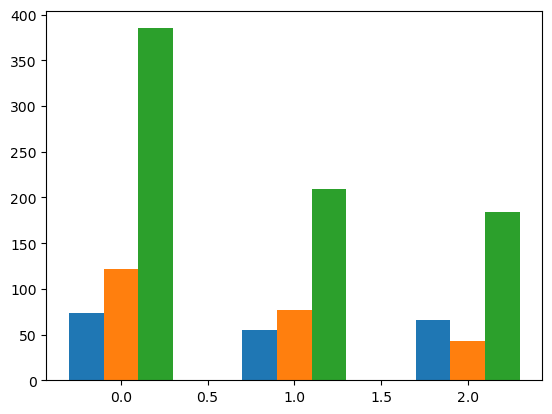

In [175]:
# Create a comparative bar chart
plt.bar(x - width, atiku_sizes, width, label='Atiku')
plt.bar(x, peter_obi_sizes, width, label='Peter Obi')
plt.bar(x + width, tinubu_sizes, width, label='Tinubu')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


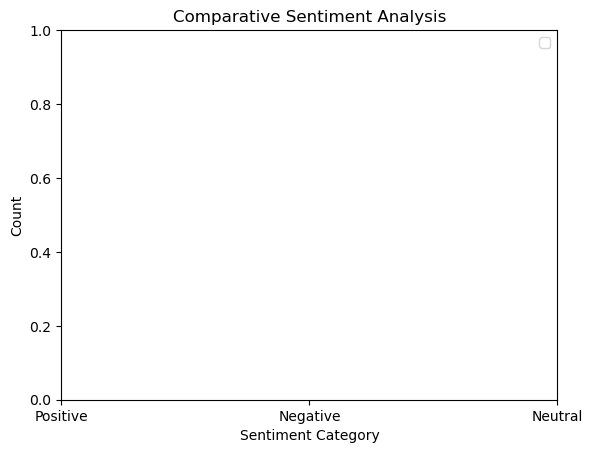

In [177]:
plt.xticks(x, labels)
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.title('Comparative Sentiment Analysis')
plt.legend()
plt.show()


In [179]:
import numpy as np
import matplotlib.pyplot as plt


In [181]:
# Define 'x' and 'width'
x = np.arange(len(labels))
width = 0.2  # Define the width of the bars


<BarContainer object of 3 artists>

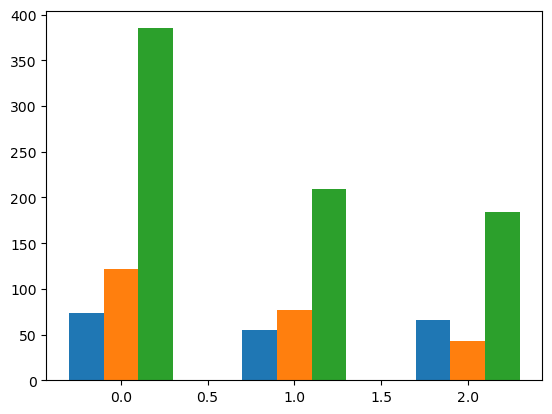

In [183]:
# Create a comparative bar chart
plt.bar(x - width, atiku_sizes, width, label='Atiku')
plt.bar(x, peter_obi_sizes, width, label='Peter Obi')
plt.bar(x + width, tinubu_sizes, width, label='Tinubu')


Text(0.5, 1.0, 'Comparative Sentiment Analysis')

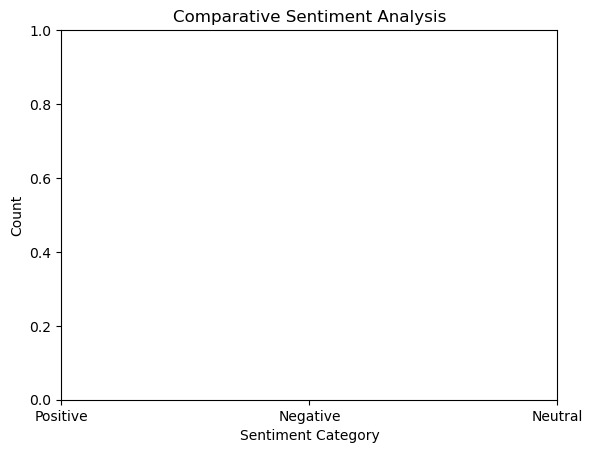

In [185]:
plt.xticks(x, labels)
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.title('Comparative Sentiment Analysis')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


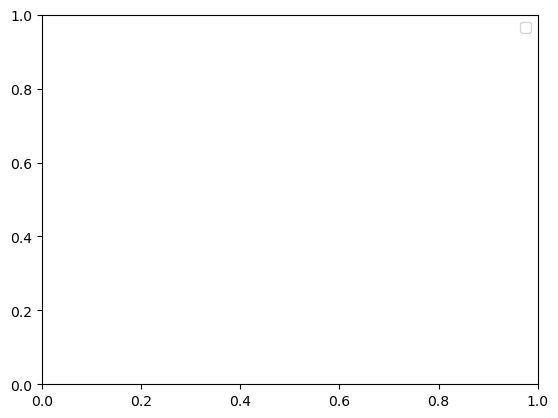

In [187]:
# Add legend with loc='best' to automatically find the best location
plt.legend(loc='best')

plt.show()


(array([[  1.,   0.,   0.,   4.,   2.,   2.,   0.,   2.,   2.,   3.,   5.,
           2.,   1.,   2.,   2.,   5.,   3.,   0.,  10.,   2.,   3.,   3.,
           0.,   1.,  65.,   1.,   5.,   1.,   3.,   5.,   0.,   5.,   2.,
           3.,   4.,   3.,   3.,   7.,   2.,   5.,   7.,   0.,   2.,   5.,
           3.,   4.,   3.,   0.,   0.,   2.],
        [  1.,   1.,   1.,   5.,   3.,   7.,   7.,   4.,   0.,   2.,   5.,
           4.,   6.,   3.,   4.,   3.,   4.,   3.,   2.,   5.,   5.,   1.,
           1.,   0.,  42.,   1.,   5.,   1.,   1.,   5.,   1.,   5.,   2.,
           7.,   2.,  10.,   4.,   7.,   7.,  12.,   6.,   8.,   8.,   6.,
           5.,   3.,   3.,   8.,   2.,   4.],
        [  5.,   7.,   2.,   7.,   6.,   7.,   4.,   6.,  10.,  14.,  16.,
          11.,  10.,  13.,   8.,  17.,  17.,   8.,   9.,   7.,   2.,  10.,
           3.,  11., 182.,   1.,  14.,   8.,  12.,  11.,   6.,  20.,   5.,
          17.,  17.,  17.,   8.,  20.,  23.,  34.,  46.,  14.,  15.,  13.,
        

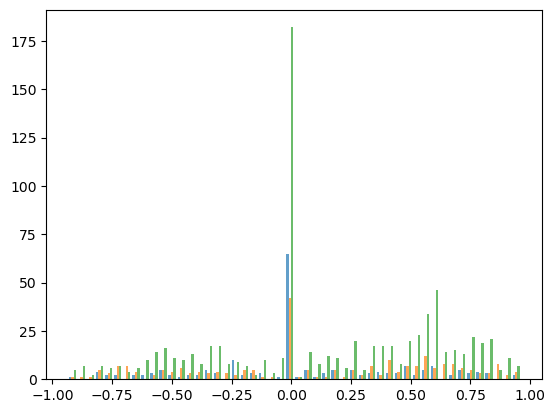

In [189]:
plt.hist([atiku_df['sentiment'], peter_obi_df['sentiment'], tinubu_df['sentiment']], 
         label=['Atiku', 'Peter Obi', 'Tinubu'], 
         alpha=0.7, 
         bins=50)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


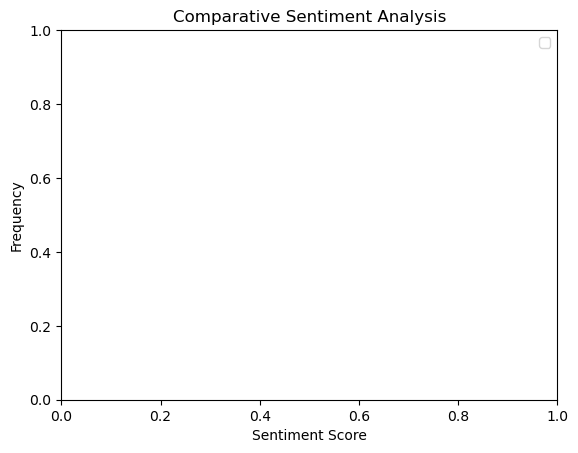

In [191]:

plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.title('Comparative Sentiment Analysis')
plt.legend(loc='best')
plt.show()


In [193]:
combined_sentiment = pd.concat([atiku_df['sentiment'], peter_obi_df['sentiment'], tinubu_df['sentiment']])


In [195]:
labels = ['Atiku', 'Peter Obi', 'Tinubu']

(array([[  1.,   0.,   0.,   4.,   2.,   2.,   0.,   2.,   2.,   3.,   5.,
           2.,   1.,   2.,   2.,   5.,   3.,   0.,  10.,   2.,   3.,   3.,
           0.,   1.,  65.,   1.,   5.,   1.,   3.,   5.,   0.,   5.,   2.,
           3.,   4.,   3.,   3.,   7.,   2.,   5.,   7.,   0.,   2.,   5.,
           3.,   4.,   3.,   0.,   0.,   2.],
        [  1.,   1.,   1.,   5.,   3.,   7.,   7.,   4.,   0.,   2.,   5.,
           4.,   6.,   3.,   4.,   3.,   4.,   3.,   2.,   5.,   5.,   1.,
           1.,   0.,  42.,   1.,   5.,   1.,   1.,   5.,   1.,   5.,   2.,
           7.,   2.,  10.,   4.,   7.,   7.,  12.,   6.,   8.,   8.,   6.,
           5.,   3.,   3.,   8.,   2.,   4.],
        [  5.,   7.,   2.,   7.,   6.,   7.,   4.,   6.,  10.,  14.,  16.,
          11.,  10.,  13.,   8.,  17.,  17.,   8.,   9.,   7.,   2.,  10.,
           3.,  11., 182.,   1.,  14.,   8.,  12.,  11.,   6.,  20.,   5.,
          17.,  17.,  17.,   8.,  20.,  23.,  34.,  46.,  14.,  15.,  13.,
        

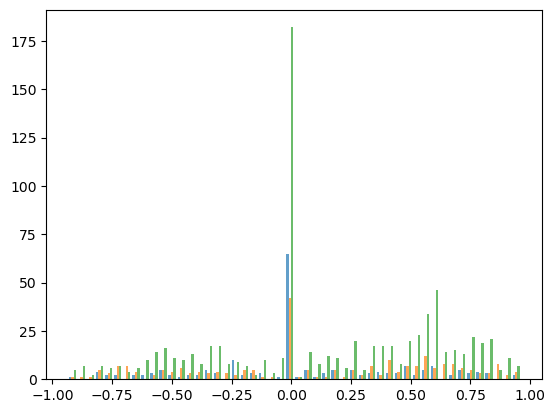

In [197]:
plt.hist([atiku_df['sentiment'], peter_obi_df['sentiment'], tinubu_df['sentiment']], 
         label=labels, 
         alpha=0.7, 
         bins=50)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


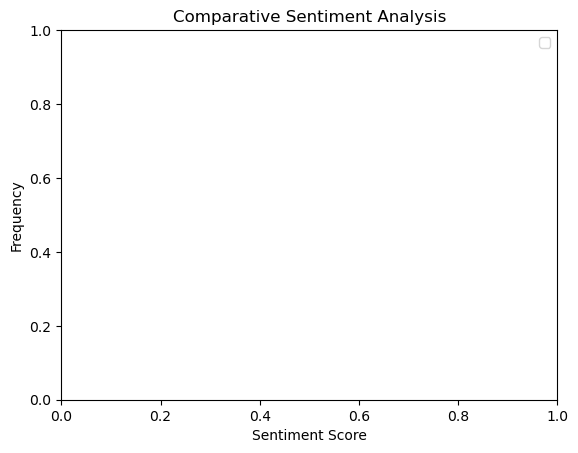

In [199]:

plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.title('Comparative Sentiment Analysis')
plt.legend(loc='best')
plt.show()


In [201]:
combined_positive = atiku_positive + peter_obi_positive + tinubu_positive
combined_negative = atiku_negative + peter_obi_negative + tinubu_negative
combined_neutral = atiku_neutral + peter_obi_neutral + tinubu_neutral

In [203]:
labels = ['Positive', 'Negative', 'Neutral']
combined_sizes = [combined_positive, combined_negative, combined_neutral]


In [205]:
x = np.arange(len(labels))
width = 0.2


<BarContainer object of 3 artists>

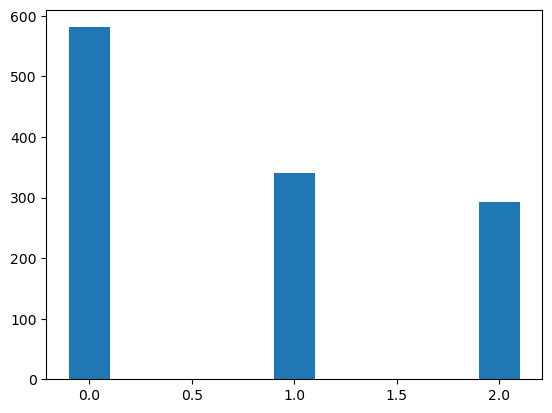

In [207]:
plt.bar(x, combined_sizes, width)


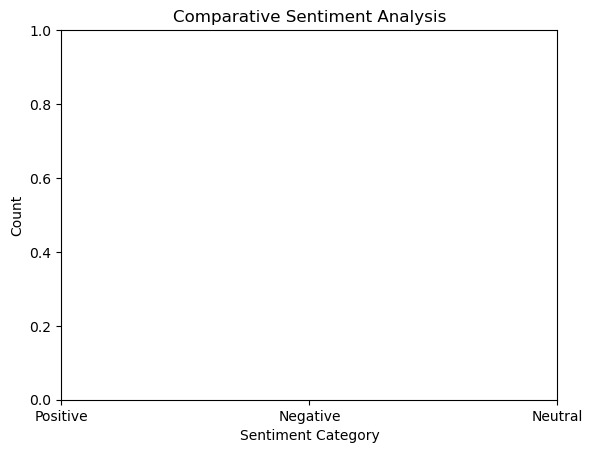

In [209]:
plt.xticks(x, labels)
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.title('Comparative Sentiment Analysis')
plt.show()


In [211]:
# Positive sentiment scores for each candidate (as percentages)
atiku_positive = 37.95
tinubu_positive = 49.49
obi_positive = 50.41



In [213]:
# Create a list of positive sentiment scores
positive_sentiment = [atiku_positive, tinubu_positive, obi_positive]



In [215]:
# Create a list of candidate names
candidates = ['Atiku', 'Tinubu', 'Peter Obi']


In [217]:
# Create a list of colors for each candidate
colors = ['#ff9999', '#66b3ff', '#99ff99']


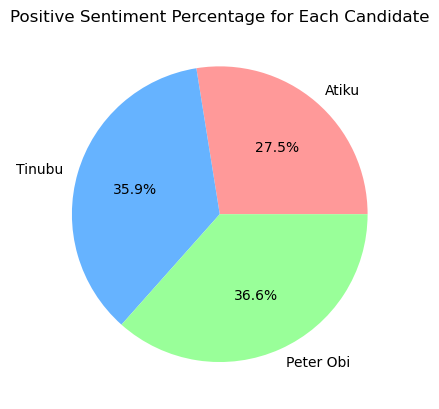

In [219]:

# Create a pie chart
plt.pie(positive_sentiment, labels=candidates, colors=colors, autopct='%1.1f%%')
plt.title('Positive Sentiment Percentage for Each Candidate')
plt.show()
